# Customer Segmentation & Churn Pattern Analytics in European Banking
**Dataset:** 10,000 European retail bank customers (France, Germany, Spain)
**Goal:** Identify which customer segments are most likely to churn, and build a predictive model to flag at-risk customers.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

RAW_FILE = Path("European_Bank.csv")
CLEAN_FILE = Path("cleaned_bank.csv")

df = pd.read_csv(RAW_FILE)

df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 1. Data Understanding & Quality Check

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [3]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0


In [5]:
# Validate binary fields
for col in ['Exited', 'HasCrCard', 'IsActiveMember']:
    print(col, df[col].unique())

Exited [1 0]
HasCrCard [1 0]
IsActiveMember [1 0]


## 2. Data Cleaning

In [6]:
df_clean = df.drop(columns=['Surname', 'Year', 'CustomerId'], errors='ignore')
df_clean.shape

(10000, 11)

## 3. Overall Churn Rate

In [7]:
churn_rate = df_clean['Exited'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")
print(f"Churned: {df_clean['Exited'].sum()} | Retained: {(df_clean['Exited']==0).sum()}")

Overall Churn Rate: 20.37%
Churned: 2037 | Retained: 7963


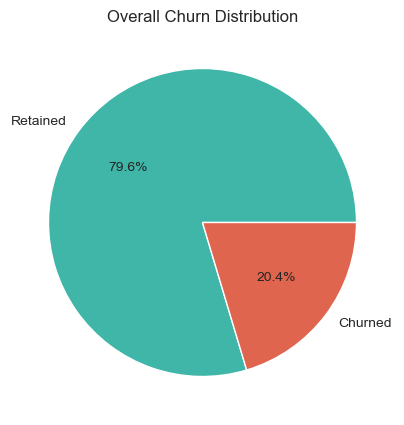

In [8]:
plt.figure(figsize=(5,5))
df_clean['Exited'].map({0:'Retained',1:'Churned'}).value_counts().plot.pie(
    autopct='%1.1f%%', colors=['#3FB6A8','#E0654F'])
plt.title("Overall Churn Distribution")
plt.ylabel("")
plt.show()

## 4. Customer Segmentation
Creating 4 segmentation dimensions as required: Age, Credit Score, Tenure, Balance.

In [9]:
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=[18,30,45,60,100], labels=['<30','30-45','46-60','60+'])
df_clean['CreditScoreBand'] = pd.cut(df_clean['CreditScore'], bins=[0,580,700,1000], labels=['Low','Medium','High'])
df_clean['TenureGroup'] = pd.cut(df_clean['Tenure'], bins=[-1,2,5,10], labels=['New','Mid-term','Long-term'])
df_clean['BalanceSegment'] = pd.cut(df_clean['Balance'], bins=[-1,0,100000,1e9], labels=['Zero','Low','High'])
df_clean[['AgeGroup','CreditScoreBand','TenureGroup','BalanceSegment']].head()

,AgeGroup,CreditScoreBand,TenureGroup,BalanceSegment
0,30-45,Medium,New,Zero
1,30-45,Medium,New,Low
2,30-45,Low,Long-term,High
3,30-45,Medium,New,Zero
4,30-45,High,New,High


## 5. Geography Analysis

Geography
Germany    32.443204
Spain      16.673395
France     16.154767
Name: Exited, dtype: float64


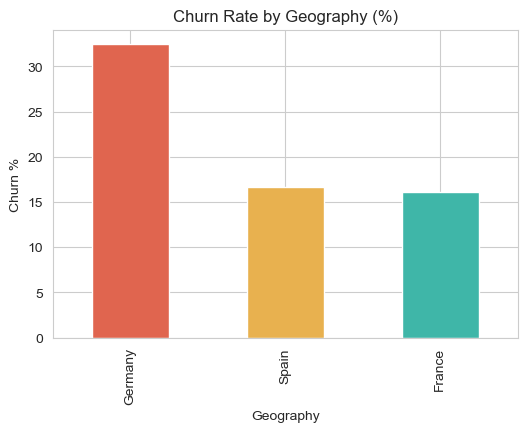

In [10]:
geo_churn = df_clean.groupby('Geography')['Exited'].mean().sort_values(ascending=False) * 100
print(geo_churn)

plt.figure(figsize=(6,4))
geo_churn.plot(kind='bar', color=['#E0654F','#E8B14F','#3FB6A8'])
plt.title("Churn Rate by Geography (%)")
plt.ylabel("Churn %")
plt.show()

**Insight:** Germany shows the highest churn rate, roughly double that of France and Spain — likely driven by local competitive or service factors.

## 6. Gender Analysis

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


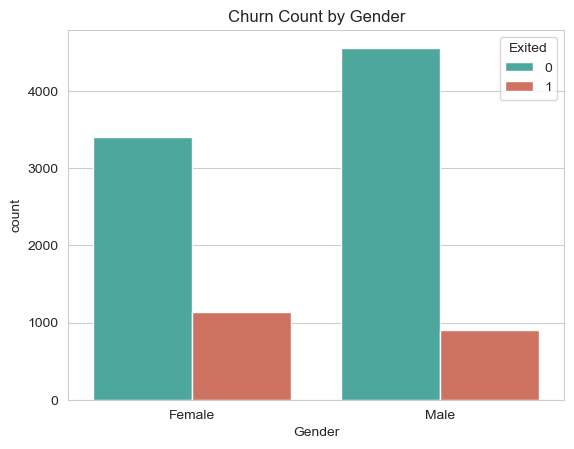

In [11]:
gender_churn = df_clean.groupby('Gender')['Exited'].mean() * 100
print(gender_churn)

sns.countplot(data=df_clean, x='Gender', hue='Exited', palette=['#3FB6A8','#E0654F'])
plt.title("Churn Count by Gender")
plt.show()

**Insight:** Female customers churn at a meaningfully higher rate than male customers.

## 7. Age Analysis

AgeGroup
<30       7.502569
30-45    15.740584
46-60    51.123254
60+      24.784483
Name: Exited, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_5564\1211928269.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df_clean.groupby('AgeGroup')['Exited'].mean().reindex(age_order) * 100


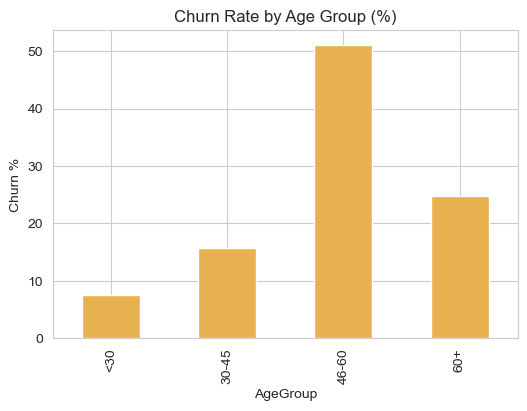

In [12]:
age_order = ['<30','30-45','46-60','60+']
age_churn = df_clean.groupby('AgeGroup')['Exited'].mean().reindex(age_order) * 100
print(age_churn)

plt.figure(figsize=(6,4))
age_churn.plot(kind='bar', color='#E8B14F')
plt.title("Churn Rate by Age Group (%)")
plt.ylabel("Churn %")
plt.show()

**Insight:** The 46-60 age group shows by far the highest churn risk — over 3x the rate of customers under 30. This is the single strongest demographic risk factor.

## 8. Credit Score Analysis

C:\Users\Dell\AppData\Local\Temp\ipykernel_5564\2101855760.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cs_churn = df_clean.groupby('CreditScoreBand')['Exited'].mean().reindex(cs_order) * 100


CreditScoreBand
Low       22.147931
Medium    19.772879
High      19.865212
Name: Exited, dtype: float64


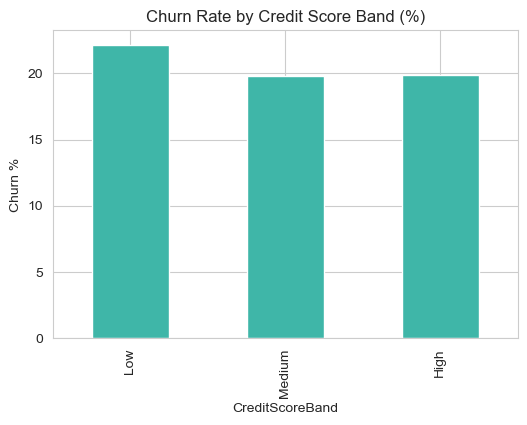

In [13]:
cs_order = ['Low','Medium','High']
cs_churn = df_clean.groupby('CreditScoreBand')['Exited'].mean().reindex(cs_order) * 100
print(cs_churn)

cs_churn.plot(kind='bar', color='#3FB6A8', figsize=(6,4))
plt.title("Churn Rate by Credit Score Band (%)")
plt.ylabel("Churn %")
plt.show()

**Insight:** Credit score has a weak relationship with churn — all bands fall in a similar 19-22% range.

## 9. Balance Analysis

C:\Users\Dell\AppData\Local\Temp\ipykernel_5564\3827664246.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Exited', y='Balance', palette=['#3FB6A8','#E0654F'])


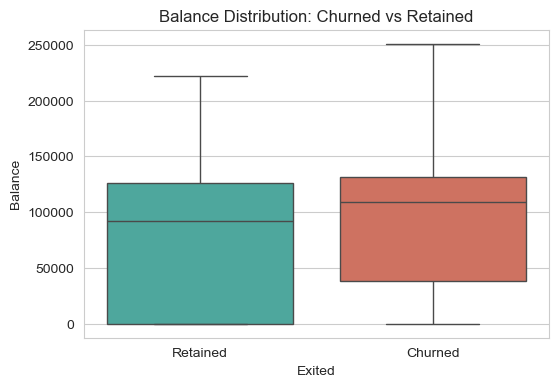

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_clean, x='Exited', y='Balance', palette=['#3FB6A8','#E0654F'])
plt.title("Balance Distribution: Churned vs Retained")
plt.xticks([0,1], ['Retained','Churned'])
plt.show()

In [15]:
bal_order = ['Zero','Low','High']
bal_churn = df_clean.groupby('BalanceSegment')['Exited'].mean().reindex(bal_order) * 100
print(bal_churn)

BalanceSegment
Zero    13.823611
Low     20.580808
High    25.234424
Name: Exited, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_5564\196632443.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bal_churn = df_clean.groupby('BalanceSegment')['Exited'].mean().reindex(bal_order) * 100


**Insight:** High-balance customers churn at a higher rate than zero-balance customers — a counterintuitive and important finding, since these are the bank's most valuable customers.

## 10. Tenure Analysis

C:\Users\Dell\AppData\Local\Temp\ipykernel_5564\2147978860.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df_clean.groupby('TenureGroup')['Exited'].mean().reindex(ten_order) * 100


TenureGroup
New          21.153846
Mid-term     20.764120
Long-term    19.670672
Name: Exited, dtype: float64


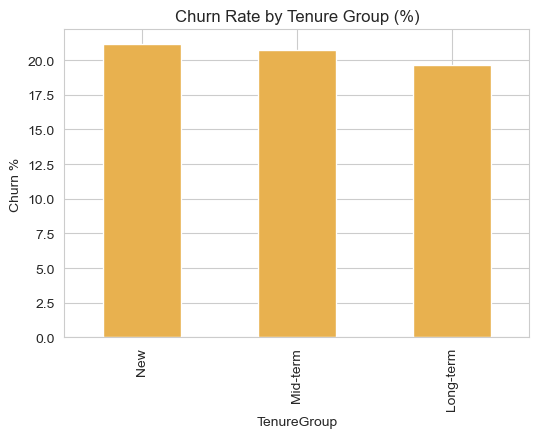

In [16]:
ten_order = ['New','Mid-term','Long-term']
tenure_churn = df_clean.groupby('TenureGroup')['Exited'].mean().reindex(ten_order) * 100
print(tenure_churn)

tenure_churn.plot(kind='bar', color='#E8B14F', figsize=(6,4))
plt.title("Churn Rate by Tenure Group (%)")
plt.ylabel("Churn %")
plt.show()

**Insight:** Tenure alone is not a strong churn driver — rates stay close to the overall average across all groups.

## 11. Product Ownership Analysis

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


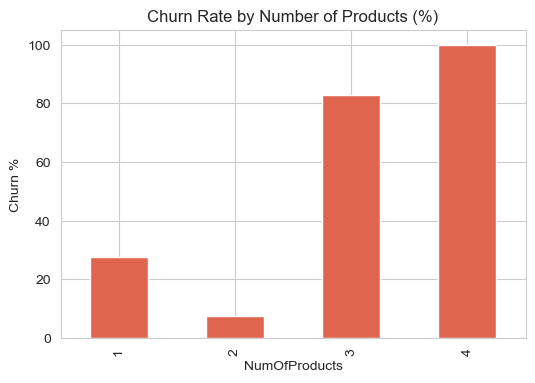

In [17]:
prod_churn = df_clean.groupby('NumOfProducts')['Exited'].mean() * 100
print(prod_churn)

prod_churn.plot(kind='bar', color='#E0654F', figsize=(6,4))
plt.title("Churn Rate by Number of Products (%)")
plt.ylabel("Churn %")
plt.show()

**Insight:** Customers with exactly 2 products are the most loyal (lowest churn). Customers with 3 or 4 products show extremely high churn — this is a small but critical segment to investigate, since it could indicate over-selling, dissatisfaction, or forced bundling.

## 12. Engagement Analysis

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


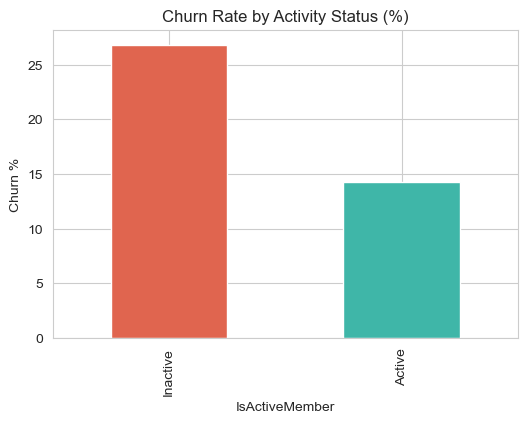

In [18]:
active_churn = df_clean.groupby('IsActiveMember')['Exited'].mean() * 100
print(active_churn)

active_churn.rename({0:'Inactive',1:'Active'}).plot(kind='bar', color=['#E0654F','#3FB6A8'], figsize=(6,4))
plt.title("Churn Rate by Activity Status (%)")
plt.ylabel("Churn %")
plt.show()

**Insight:** Inactive members churn at nearly double the rate of active members — this is one of the strongest and most actionable churn indicators, since activity can be monitored in real time.

## 13. High-Value Customer Analysis

In [19]:
hv_threshold = df_clean['Balance'].quantile(0.75)
hv = df_clean[df_clean['Balance'] >= hv_threshold]

print(f"High-value threshold (top 25% by balance): €{hv_threshold:,.0f}")
print(f"High-value churn rate: {hv['Exited'].mean()*100:.2f}%")
print(f"Overall churn rate: {df_clean['Exited'].mean()*100:.2f}%")

print("\nAverage balance comparison:")
print(df_clean.groupby('Exited')['Balance'].mean())

High-value threshold (top 25% by balance): €127,644
High-value churn rate: 23.68%
Overall churn rate: 20.37%

Average balance comparison:
Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64


**Insight:** Churned customers hold higher average balances than retained customers — confirming that the bank is losing financially valuable relationships at an above-average rate.

## 14. Geography × Age Interaction

C:\Users\Dell\AppData\Local\Temp\ipykernel_5564\2907253460.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_clean.pivot_table(values='Exited', index='AgeGroup', columns='Geography', aggfunc='mean').reindex(age_order) * 100


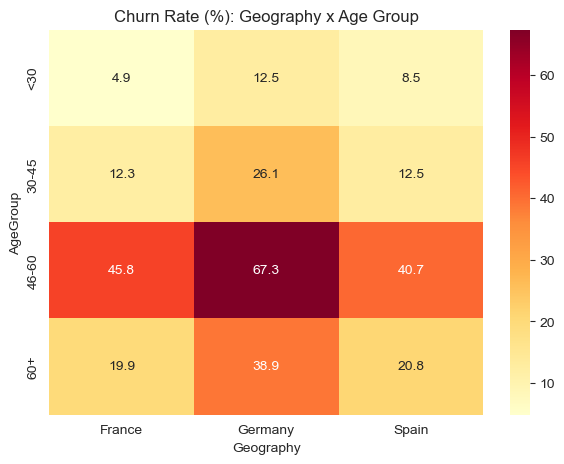

In [20]:
pivot = df_clean.pivot_table(values='Exited', index='AgeGroup', columns='Geography', aggfunc='mean').reindex(age_order) * 100
plt.figure(figsize=(7,5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title("Churn Rate (%): Geography x Age Group")
plt.show()

**Insight:** The 46-60 risk effect appears across all three countries but is most severe when combined with Germany — these two risk factors compound.

## 15. Key Performance Indicators (KPI Summary)

In [21]:
kpis = {
    "Overall Churn Rate": f"{df_clean['Exited'].mean()*100:.2f}%",
    "High-Value Churn Rate": f"{hv['Exited'].mean()*100:.2f}%",
    "Female Churn Rate": f"{gender_churn['Female']:.2f}%",
    "Germany Churn Rate": f"{geo_churn['Germany']:.2f}%",
    "Inactive Member Churn": f"{active_churn[0]:.2f}%",
    "Highest Risk Age Group": "46-60",
    "Most Loyal Product Group": "2 Products",
}
for k,v in kpis.items():
    print(f"{k}: {v}")

Overall Churn Rate: 20.37%
High-Value Churn Rate: 23.68%
Female Churn Rate: 25.07%
Germany Churn Rate: 32.44%
Inactive Member Churn: 26.85%
Highest Risk Age Group: 46-60
Most Loyal Product Group: 2 Products


## 16. Predictive Modeling — Churn Prediction
We compare Logistic Regression (baseline, interpretable) against Random Forest (higher accuracy, handles non-linear interactions).

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

features = ['CreditScore','Geography','Gender','Age','Tenure','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary']
X = pd.get_dummies(df_clean[features], columns=['Geography','Gender'], drop_first=True)
y = df_clean['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
# Logistic Regression (scaled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_preds))
print("Precision:", precision_score(y_test, log_preds))
print("Recall:", recall_score(y_test, log_preds))
print("F1:", f1_score(y_test, log_preds))
print("ROC-AUC:", roc_auc_score(y_test, log_probs))

Logistic Regression Results
Accuracy: 0.7135
Precision: 0.38722826086956524
Recall: 0.7002457002457002
F1: 0.49868766404199477
ROC-AUC: 0.7771376923919298


In [24]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:,1]

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("Precision:", precision_score(y_test, rf_preds))
print("Recall:", recall_score(y_test, rf_preds))
print("F1:", f1_score(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))

Random Forest Results
Accuracy: 0.823
Precision: 0.549165120593692
Recall: 0.7272727272727273
F1: 0.6257928118393234
ROC-AUC: 0.8670010534417313


**Model comparison:** Random Forest outperforms Logistic Regression on ROC-AUC and F1, because churn is driven by non-linear interactions (e.g., age combined with geography combined with product count). Logistic Regression is kept as an interpretable baseline.

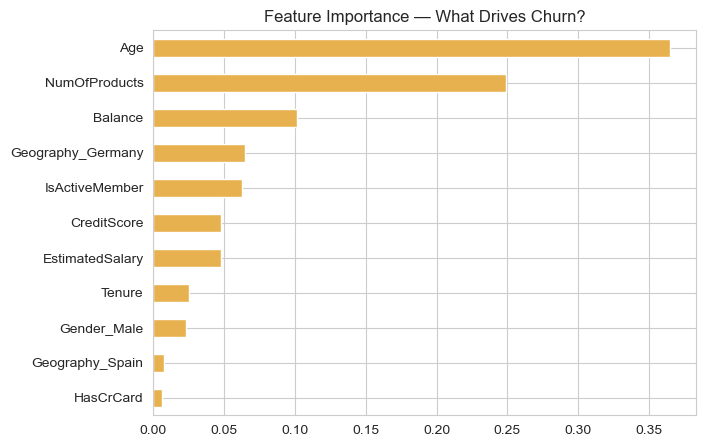

Age                  0.364894
NumOfProducts        0.248924
Balance              0.101386
Geography_Germany    0.064730
IsActiveMember       0.062650
CreditScore          0.047915
EstimatedSalary      0.047568
Tenure               0.025342
Gender_Male          0.023310
Geography_Spain      0.007446
HasCrCard            0.005834
dtype: float64

In [25]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(7,5))
importances.plot(kind='barh', color='#E8B14F')
plt.title("Feature Importance — What Drives Churn?")
plt.gca().invert_yaxis()
plt.show()
importances

**Insight:** Age and Number of Products are the two strongest predictors of churn — even more influential than geography in the model, despite geography showing a clear pattern in the raw segment analysis.

## 17. Business Recommendations

1. **Target inactive customers** with personalized re-engagement campaigns and loyalty programs — this is the most actionable, real-time-trackable churn signal.
2. **Build a dedicated retention program for Germany**, the highest-risk market at 32% churn.
3. **Protect high-balance customers** with premium service tiers and dedicated relationship managers, since they churn above the average rate despite their value.
4. **Focus on the 46-60 age segment**, the single largest demographic risk factor (51% churn).
5. **Investigate the 3-4 product segment** for over-selling or bundling issues, since churn jumps sharply beyond 2 products.
6. **Increase cross-selling toward the 2-product sweet spot**, which shows the lowest churn of any product tier.

## 18. Conclusion
Churn in this dataset is concentrated, not random — driven primarily by age, product ownership, geography, and engagement level. A segmentation-driven retention strategy targeting these specific high-risk groups offers a clear, data-backed path to reducing the 20.4% churn rate and protecting the bank's most valuable customer relationships.